# SelectKBest (χ²) + TruncatedSVD(500) no TF-IDF, com metadados spaCy

**Pergunta:** filtrar os n-gramas do TF-IDF por χ² **antes** do `TruncatedSVD(500)` reduz o overfitting do texto e deixa o bloco spaCy contribuir mais, sem perder F1 em notícias não vistas?

**Setup fixo, sem nova busca:**
- M2 = texto + meta_spacy, `LinearSVC(C=1, class_weight="balanced", dual=False)`, peso do spaCy **w = 0,03** (melhor do Fake.br, notebook 10).
- Texto: `TF-IDF word+char → SelectKBest(chi2, k) → TruncatedSVD(500) → Normalizer`.
  - **d = 500 fixo**, o melhor d reduzido do notebook 11 (F1 CV 0,9218).
  - Varia só **k ∈ {1.000; 2.000; 5.000; 10.000; 20.000; 50.000; todas}**. k precisa ser > 500.
  - `k = todas` é o M2 com d=500 do notebook 11.
- B0 no mesmo pipeline de texto, sem spaCy, para medir quanto o spaCy acrescenta em cada k. O SVD é o mesmo nos dois, então o custo é compartilhado.
- Mesmos folds: `StratifiedKFold(5, shuffle=True, random_state=42)`. χ², SVD e scaler são ajustados **dentro de cada fold**. O SVD roda em float32 por limite de memória.
- Referências: o M2 com texto completo (F1 CV 0,9344, gap 0,066) e o M2 com d=500 sem χ² (0,9218, gap 0,036).

**Regra de escolha de k, a mesma do notebook 11, fixada antes de rodar e só com a CV:** entre os k com Δ pareado contra o M2 completo **≥ −0,01**, escolher o de menor gap. Se nenhum passar, o k com melhor F1 CV vai ao teste só para informação.

**FakeRecogna:** só espiada (títulos de ~13 palavras contra treino de 100). Não escolhe nada.

In [1]:
# Resolve input and output paths from the supervised research root.
from pathlib import Path
import sys

_cwd = Path.cwd().resolve()
_candidates = [candidate for parent in (_cwd, *_cwd.parents)
               for candidate in (parent, parent / "machine-learning/supervised-learning")]
ROOT = next((candidate for candidate in _candidates
             if (candidate / "modelo_olimpo.py").is_file()
             and (candidate / "history/baselines/01_Data_Prep.ipynb").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from within the Olimpo repository.")
DATA = ROOT / "data"
HISTORY_RESULTS = ROOT / "history/resultados"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Original experiment starts here.
import gc
import time
import re

import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, Normalizer, FunctionTransformer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

pd.set_option("display.width", 200)

X_tr, X_te, y_tr, y_te = joblib.load((DATA / 'dados_preparados.pkl'))
configs = joblib.load((DATA / 'transformers.pkl'))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

res10 = pd.read_csv((HISTORY_RESULTS / 'resultados_svm_meta_cv.csv'))
m2_10 = res10[(res10.config == "M2") & (res10.k_chi2 == "all")].sort_values("f1_cv").iloc[-1]
C, W = float(m2_10.C), float(m2_10.w_meta)
D = 500
print(f"Fixos: C={C}, w={W}, d={D}")

# meta_spacy final do notebook 10, seção 4
META_SPACY = ['pos_ADJ', 'pos_ADP', 'pos_AUX', 'pos_CCONJ', 'pos_DET', 'pos_NOUN', 'pos_NUM', 'pos_PRON',
              'pos_PROPN', 'pos_PUNCT', 'pos_VERB', 'dep_nsubj', 'dep_obj', 'dep_obl', 'dep_nmod', 'dep_advmod',
              'dep_amod', 'dep_ccomp', 'dep_xcomp', 'dep_mark', 'taxa_sentencas', 'tam_medio_sentenca_sp',
              'verbo_subjuntivo', 'pessoa_1_2']
feats = pd.read_parquet((DATA / 'metadados_spacy.parquet'))  # gerado pelo notebook 10
X_tr = X_tr.join(feats.loc[X_tr.index, META_SPACY])
X_te = X_te.join(feats.loc[X_te.index, META_SPACY])

SVC = LinearSVC(C=C, class_weight="balanced", random_state=42, max_iter=20000, dual=False)
KS = [1000, 2000, 5000, 10000, 20000, 50000, "all"]

Fixos: C=1.0, w=0.03, d=500


## 1. Blocos por fold

**Pergunta:** quanto custa preparar cada fold? Em cada fold: TF-IDF no treino do fold → χ² com cada k, ajustado no treino do fold → SVD(500) → Normalizer. O M2 com texto completo (sem χ² e sem SVD) também é guardado, como referência pareada.

In [2]:
def meta_pipe():
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])

folds = []
t_total = time.time()
for i, (tr, va) in enumerate(cv.split(X_tr, y_tr)):
    Xa, Xb = X_tr.iloc[tr], X_tr.iloc[va]
    f = {"y_tr": y_tr.iloc[tr].values, "y_va": y_tr.iloc[va].values, "txt": {}, "var": {}}
    ct = ColumnTransformer(configs["word+char"]).fit(Xa)
    Ta, Tb = ct.transform(Xa).tocsr(), ct.transform(Xb).tocsr()
    f["txt"]["completo"] = (Ta, Tb)
    for k in KS:
        if k == "all":
            Sa, Sb = Ta, Tb
        else:
            sel = SelectKBest(chi2, k=k).fit(Ta, f["y_tr"])
            Sa, Sb = sel.transform(Ta), sel.transform(Tb)
        svd = TruncatedSVD(n_components=D, random_state=42).fit(Sa.astype(np.float32))
        norm = Normalizer()
        f["txt"][k] = (norm.transform(svd.transform(Sa.astype(np.float32))),
                       norm.transform(svd.transform(Sb.astype(np.float32))))
        f["var"][k] = svd.explained_variance_ratio_.sum()
        del svd, Sa, Sb
        gc.collect()
    mp = meta_pipe().fit(Xa[META_SPACY])
    f["meta"] = (mp.transform(Xa[META_SPACY]), mp.transform(Xb[META_SPACY]))
    folds.append(f)
    print(f"fold {i + 1} pronto ({time.time() - t_total:.0f}s acumulados)", flush=True)

var = pd.DataFrame([f["var"] for f in folds]).mean()
print("\nVariância explicada média pelo SVD(500) depois do χ²:")
print(var.round(4).to_string())

fold 1 pronto (57s acumulados)


fold 2 pronto (112s acumulados)


fold 3 pronto (168s acumulados)


fold 4 pronto (224s acumulados)


fold 5 pronto (280s acumulados)



Variância explicada média pelo SVD(500) depois do χ²:
1000     0.9866
2000     0.8847
5000     0.7267
10000    0.6224
20000    0.5312
50000    0.4367
all      0.3554


**Conclusão:** com o χ², o SVD(500) passa a reter muito mais variância: **62% com k=10 mil**, contra 35,5% sem χ². Isso acontece porque a projeção atua sobre um vocabulário já filtrado pelos n-gramas mais discriminativos.

## 2. CV: F1 treino, F1 CV e gap por k

**Pergunta:** filtrar n-gramas antes do SVD melhora a validação ou só muda o gap? Quanto o spaCy acrescenta em cada k?

Δ pareado por fold contra o M2 com texto completo (`delta_vs_m2`), contra o M2 com d=500 sem χ² (`delta_vs_svd500`, linha `k=all`) e ganho do spaCy no mesmo k (`ganho_spacy` = M2 − B0).

In [3]:
def montar(f, k, com_meta, parte):
    T = f["txt"][k][parte]
    if not com_meta:
        return T
    M = W * f["meta"][parte]
    return sp.hstack([T, sp.csr_matrix(M)]).tocsr() if sp.issparse(T) else np.hstack([T, M])

def avaliar(k, com_meta):
    tr_s, va_s = [], []
    for f in folds:
        A, B = montar(f, k, com_meta, 0), montar(f, k, com_meta, 1)
        m = clone(SVC).fit(A, f["y_tr"])
        tr_s.append(f1_score(f["y_tr"], m.predict(A), average="macro"))
        va_s.append(f1_score(f["y_va"], m.predict(B), average="macro"))
    return {"config": "M2" if com_meta else "B0", "k_chi2": k, "d_svd": D if k != "completo" else "completo",
            "f1_treino": np.mean(tr_s), "f1_cv": np.mean(va_s), "f1_cv_std": np.std(va_s), "folds": np.array(va_s)}

linhas = [avaliar(k, m) for m in (False, True) for k in ["completo"] + KS]
res = pd.DataFrame(linhas)
F = np.vstack(res.folds.values)
ref_m2 = res.query("config == 'M2' and k_chi2 == 'completo'").folds.iloc[0]
ref_svd = res.query("config == 'M2' and k_chi2 == 'all'").folds.iloc[0]
res["gap"] = res.f1_treino - res.f1_cv
res["delta_vs_m2"] = (F - ref_m2).mean(axis=1)
res["delta_vs_m2_std"] = (F - ref_m2).std(axis=1)
res["folds_melhores_vs_m2"] = ((F - ref_m2) > 0).sum(axis=1)
res["delta_vs_svd500"] = (F - ref_svd).mean(axis=1)
res["folds_melhores_vs_svd500"] = ((F - ref_svd) > 0).sum(axis=1)
b0 = res[res.config == "B0"].set_index("k_chi2").f1_cv
res["ganho_spacy"] = np.where(res.config == "M2", res.f1_cv - res.k_chi2.map(b0), np.nan)

COLS = ["config", "k_chi2", "d_svd", "f1_treino", "f1_cv", "f1_cv_std", "gap", "delta_vs_m2", "delta_vs_m2_std",
        "folds_melhores_vs_m2", "delta_vs_svd500", "folds_melhores_vs_svd500", "ganho_spacy"]
res[COLS].to_csv((ROOT / 'resultados_selectk_svd500_cv.csv'), index=False)
print("Salvo: resultados_selectk_svd500_cv.csv")
res[COLS].round(4)

Salvo: resultados_selectk_svd500_cv.csv


,config,k_chi2,d_svd,f1_treino,f1_cv,f1_cv_std,gap,delta_vs_m2,delta_vs_m2_std,folds_melhores_vs_m2,delta_vs_svd500,folds_melhores_vs_svd500,ganho_spacy
0,B0,completo,completo,1.0000,0.9295,0.0099,0.0705,-0.0049,0.0026,0,0.0077,4,NaN
1,B0,1000,500,0.9506,0.9054,0.0088,0.0452,-0.0290,0.0118,0,-0.0165,0,NaN
2,B0,2000,500,0.9589,0.9109,0.0088,0.0480,-0.0234,0.0106,0,-0.0109,0,NaN
3,B0,5000,500,0.9635,0.9168,0.0115,0.0467,-0.0175,0.0080,0,-0.0050,0,NaN
4,B0,10000,500,0.9675,0.9198,0.0092,0.0478,-0.0146,0.0083,0,-0.0021,1,NaN
5,B0,20000,500,0.9703,0.9227,0.0104,0.0476,-0.0116,0.0034,0,0.0009,2,NaN
6,B0,50000,500,0.9681,0.9250,0.0074,0.0432,-0.0094,0.0079,0,0.0031,3,NaN
7,B0,all,500,0.9519,0.9152,0.0078,0.0367,-0.0192,0.0067,0,-0.0067,0,NaN
8,M2,completo,completo,1.0000,0.9344,0.0103,0.0656,0.0000,0.0000,0,0.0125,5,0.0049
9,M2,1000,500,0.9601,0.9189,0.0102,0.0412,-0.0154,0.0103,0,-0.0029,2,0.0135


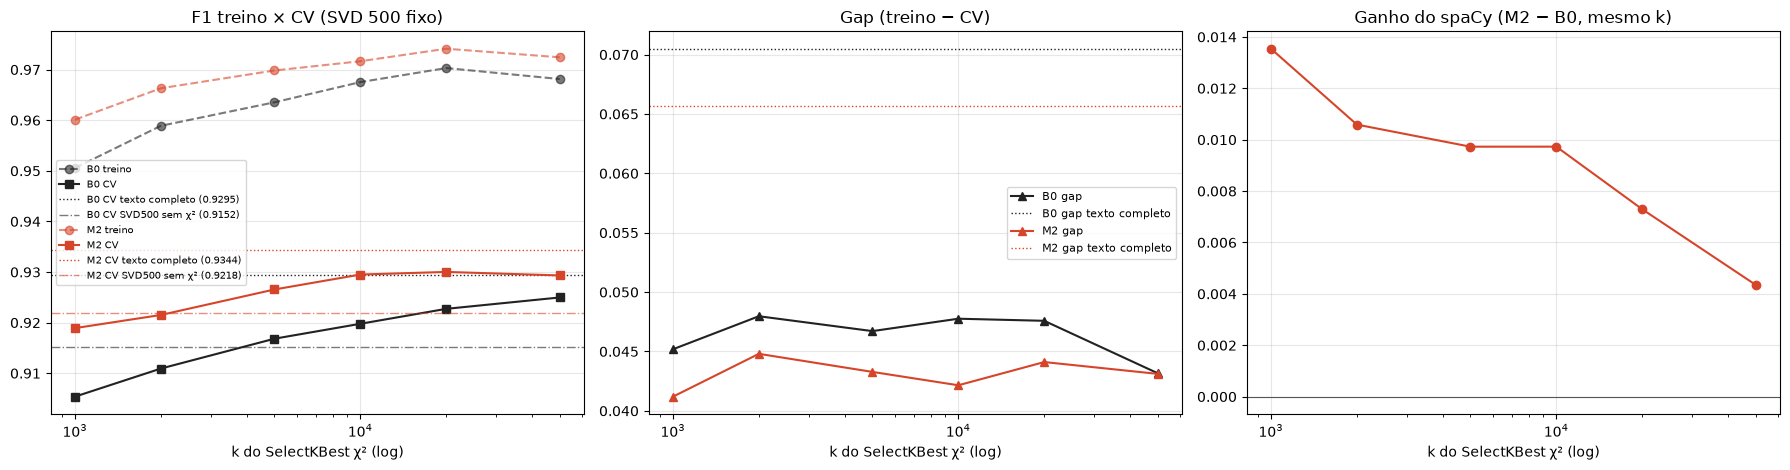

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
kx = [k for k in KS if k != "all"]
for cfg, cor in [("B0", "#222222"), ("M2", "#d6452a")]:
    s = res[(res.config == cfg) & res.k_chi2.isin(kx)]
    full = res[(res.config == cfg) & (res.k_chi2 == "completo")].iloc[0]
    svd = res[(res.config == cfg) & (res.k_chi2 == "all")].iloc[0]
    k = s.k_chi2.astype(int)
    axes[0].plot(k, s.f1_treino, "--o", color=cor, alpha=0.6, label=f"{cfg} treino")
    axes[0].plot(k, s.f1_cv, "-s", color=cor, label=f"{cfg} CV")
    axes[0].axhline(full.f1_cv, color=cor, ls=":", lw=1, label=f"{cfg} CV texto completo ({full.f1_cv:.4f})")
    axes[0].axhline(svd.f1_cv, color=cor, ls="-.", lw=1, alpha=0.6, label=f"{cfg} CV SVD500 sem χ² ({svd.f1_cv:.4f})")
    axes[1].plot(k, s.gap, "-^", color=cor, label=f"{cfg} gap")
    axes[1].axhline(full.gap, color=cor, ls=":", lw=1, label=f"{cfg} gap texto completo")
m2 = res[(res.config == "M2") & res.k_chi2.isin(kx)]
axes[2].plot(m2.k_chi2.astype(int), m2.ganho_spacy, "-o", color="#d6452a")
axes[2].axhline(0, color="#555", lw=0.8)
for ax, t in zip(axes, ["F1 treino × CV (SVD 500 fixo)", "Gap (treino − CV)", "Ganho do spaCy (M2 − B0, mesmo k)"]):
    ax.set_xscale("log"); ax.set_xlabel("k do SelectKBest χ² (log)"); ax.set_title(t); ax.grid(alpha=0.3)
axes[0].legend(fontsize=7); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Conclusão:** o χ² antes do SVD **recupera boa parte do que o SVD sozinho perdia**.

| M2, SVD 500 | F1 treino | F1 CV | Gap | Δ vs M2 completo | Δ vs SVD500 sem χ² | Ganho do spaCy |
|---|---|---|---|---|---|---|
| texto completo (sem χ², sem SVD) | 1,000 | **0,9344** | 0,066 | – | – | +0,005 |
| sem χ² (k=todas) | 0,958 | 0,9218 | 0,036 | −0,0125 (0/5) | – | +0,007 |
| **χ² k=10 mil** | 0,972 | **0,9295** | 0,042 | −0,0049 (1/5) | +0,0077 (5/5) | **+0,010** |
| χ² k=20 mil | 0,974 | 0,9300 | 0,044 | −0,0043 (0/5) | +0,0082 (5/5) | +0,007 |
| χ² k=1 mil | 0,960 | 0,9189 | 0,041 | −0,0154 (0/5) | −0,0029 (2/5) | +0,014 |

- **O M2 com χ² 10–50 mil + SVD(500) fica em ~0,930, o mesmo F1 CV do SVM atual (B0 completo, 0,9295), com gap de 0,042 contra 0,0705.** Diferente do SVD sozinho, aqui o gap cai **sem** a validação cair frente ao B0. O modelo deixa de separar o treino perfeitamente (F1 treino 0,97) e acerta as notícias não vistas tanto quanto antes.
- Contra o M2 completo (0,9344) ainda perde ~0,005, de forma consistente (0–1/5 folds).
- **O spaCy contribui o dobro** quando o texto passa pelo χ² + SVD: +0,010 com k=10 mil, contra +0,005 no texto completo.
- Com k ≤ 2 mil, o χ² corta sinal demais.

## 3. Escolha de k (só CV)

**Pergunta:** algum k reduz o gap mantendo o F1 CV empatado com o M2 completo (Δ ≥ −0,01)?

In [5]:
cand = res[(res.config == "M2") & (res.k_chi2 != "completo")]
validos = cand[cand.delta_vs_m2 >= -0.01]
if len(validos):
    escolhido = validos.sort_values("gap").iloc[0]
    print(f"k escolhido = {escolhido.k_chi2}: gap {escolhido.gap:.4f}, Δ vs M2 completo {escolhido.delta_vs_m2:+.4f}")
else:
    escolhido = cand.sort_values("f1_cv").iloc[-1]
    print("Nenhum k mantém o F1 CV dentro de −0,01 do M2 completo.")
    print(f"Para informação, vai ao teste o k com melhor F1 CV: k={escolhido.k_chi2} "
          f"(F1 CV {escolhido.f1_cv:.4f}, Δ {escolhido.delta_vs_m2:+.4f}, gap {escolhido.gap:.4f})")
K_ESC = escolhido.k_chi2

k escolhido = 10000: gap 0.0422, Δ vs M2 completo -0.0049


**Conclusão:** **k = 10 mil** é o primeiro k que passa no critério: Δ −0,0049 contra o M2 completo, com o menor gap entre os válidos (0,042). Os k ≥ 5 mil também passam.

**Atenção:** passar no critério é empatar, não ganhar. Contra o M2 completo, o k=10 mil perde em 4 dos 5 folds (1/5 melhores).

## 4. Teste interno (`X_te`, uma vez)

**Pergunta:** no teste isolado, como fica o M2 com χ²(k escolhido) + SVD(500) frente ao M2 completo e ao B0? O `Pipeline` real é reajustado no `X_tr` completo. Os números do B0 e do M2 completo repetem os do notebook 10.

In [6]:
def para_float32(X):
    return X.astype(np.float32)

def pipeline_real(k, com_meta):
    txt = ColumnTransformer(configs["word+char"])
    if k != "completo":
        passos = [("tfidf", txt)]
        if k != "all":
            passos.append(("chi2", SelectKBest(chi2, k=k)))
        passos += [("f32", FunctionTransformer(para_float32, accept_sparse=True)),
                   ("svd", TruncatedSVD(n_components=D, random_state=42)), ("norm", Normalizer())]
        txt = Pipeline(passos)
    trans, pesos = [("txt", txt, ["texto_trunc"])], {"txt": 1.0}
    if com_meta:
        trans.append(("meta", meta_pipe(), META_SPACY))
        pesos["meta"] = W
    return Pipeline([("prep", ColumnTransformer(trans, transformer_weights=pesos)), ("clf", clone(SVC))])

def metricas(conjunto, nome, k, y, pipe, X):
    score = pipe.decision_function(X)
    pred = (score > 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {"conjunto": conjunto, "config": nome, "k_chi2": k, "d_svd": D if k != "completo" else "completo",
            "f1_macro": f1_score(y, pred, average="macro"), "roc_auc": roc_auc_score(y, score),
            "pct_prev_fake": pred.mean(), "tn": tn, "fp": fp, "fn": fn, "tp": tp}

finais = {("B0", "completo"): pipeline_real("completo", False), ("M2", "completo"): pipeline_real("completo", True),
          ("M2", K_ESC): pipeline_real(K_ESC, True)}
linhas_teste = []
for (nome, k), pipe in finais.items():
    pipe.fit(X_tr, y_tr)
    linhas_teste.append(metricas("interno (Fake.br X_te)", nome, k, y_te, pipe, X_te))
pd.DataFrame(linhas_teste).round(4)

,conjunto,config,k_chi2,d_svd,f1_macro,roc_auc,pct_prev_fake,tn,fp,fn,tp
0,interno (Fake.br X_te),B0,completo,completo,0.9222,0.9830,0.4972,666,54,58,662
1,interno (Fake.br X_te),M2,completo,completo,0.9236,0.9846,0.4958,668,52,58,662
2,interno (Fake.br X_te),M2,10000,500,0.9243,0.9789,0.4951,669,51,58,662


**Conclusão:** no teste interno, o M2 com χ² k=10 mil + SVD(500) tem F1 **0,9243**, contra 0,9236 do M2 completo e 0,9222 do B0.
- O AUC fica em 0,9789, um pouco abaixo de 0,9846 e 0,9830.
- Tudo dentro do erro padrão (~±0,007). O teste confirma que a variante reduzida **não perde** F1 frente ao SVM atual.

## 5. Espiada no FakeRecogna (não escolhe nada)

**Pergunta:** o χ² antes do SVD muda a **ordenação** (AUC) fora do domínio ou só o limiar? Avaliamos todos os k, com o M2 e o B0 reajustados no `X_tr` completo. Ressalva: títulos de ~13 palavras contra treino de 100.

In [7]:
def normalizar(texto):
    texto = str(texto)
    texto = texto.translate(str.maketrans({"\x96": "-", "\x97": "-", "\x93": '"', "\x94": '"', "\x91": "'", "\x92": "'"}))
    texto = re.sub(r"[\x80-\x9f]", " ", texto)
    texto = re.sub(r"[–—]", "-", texto)
    texto = re.sub(r"[“”«»]", '"', texto)
    texto = re.sub(r"[‘’]", "'", texto)
    texto = re.sub(r"\s*(?:\[\.*\]|\.{2,}|…)", ".", texto)
    texto = re.sub(r"\d", "0", texto)
    return " ".join(texto.split())

d_ = pd.read_csv((DATA / 'FakeRecogna.csv'))
d_["dominio"] = d_.URL.fillna("").str.extract(r"https?://(?:www\.)?([^/]+)")[0]
fake = d_[(d_.Classe == 0) & (d_.dominio == "boatos.org")].copy()
fake["texto_trunc"] = fake.Titulo.str.replace(r"#boato", "", case=False, regex=True)
real = d_[d_.Classe == 1].sample(len(fake), random_state=42).copy()
real["texto_trunc"] = real.Titulo
ext = pd.concat([fake, real])
ext["texto_trunc"] = ext.texto_trunc.fillna("").map(normalizar)
ext = ext[ext.texto_trunc.str.len() > 0].reset_index(drop=True)
ext["label"] = (ext.Classe == 0).astype(int)
feats_ext = pd.read_parquet((DATA / 'metadados_spacy_fakerecogna.parquet'))  # gerado pelo notebook 10
assert len(feats_ext) == len(ext)
ext = ext.join(feats_ext[META_SPACY])

linhas_ext = []
for nome, com_meta in [("B0", False), ("M2", True)]:
    for k in ["completo"] + KS:
        pipe = finais.get((nome, k)) or pipeline_real(k, com_meta).fit(X_tr, y_tr)
        linhas_ext.append(metricas("externo (FakeRecogna títulos, espiada)", nome, k, ext["label"], pipe, ext))
        del pipe
        gc.collect()
    print(f"{nome}: ok", flush=True)

teste = pd.DataFrame(linhas_teste + linhas_ext)
teste.round(6).to_csv((ROOT / 'resultados_selectk_svd500_teste.csv'), index=False)
print("Salvo: resultados_selectk_svd500_teste.csv")
pd.DataFrame(linhas_ext).round(4)

B0: ok


M2: ok


Salvo: resultados_selectk_svd500_teste.csv


,conjunto,config,k_chi2,d_svd,f1_macro,roc_auc,pct_prev_fake,tn,fp,fn,tp
0,"externo (FakeRecogna títulos, espiada)",B0,completo,completo,0.6119,0.7072,0.7075,1046,1438,407,2077
1,"externo (FakeRecogna títulos, espiada)",B0,1000,500,0.5938,0.6565,0.5946,1249,1235,765,1719
2,"externo (FakeRecogna títulos, espiada)",B0,2000,500,0.6174,0.6516,0.5749,1353,1131,759,1725
3,"externo (FakeRecogna títulos, espiada)",B0,5000,500,0.6086,0.6642,0.6075,1256,1228,694,1790
4,"externo (FakeRecogna títulos, espiada)",B0,10000,500,0.6330,0.6860,0.5594,1428,1056,761,1723
5,"externo (FakeRecogna títulos, espiada)",B0,20000,500,0.6353,0.6855,0.5618,1428,1056,749,1735
6,"externo (FakeRecogna títulos, espiada)",B0,50000,500,0.6384,0.6913,0.5507,1462,1022,770,1714
7,"externo (FakeRecogna títulos, espiada)",B0,all,500,0.6518,0.7069,0.5541,1487,997,728,1756
8,"externo (FakeRecogna títulos, espiada)",M2,completo,completo,0.6134,0.6622,0.5934,1300,1184,720,1764
9,"externo (FakeRecogna títulos, espiada)",M2,1000,500,0.6029,0.6491,0.6186,1217,1267,678,1806


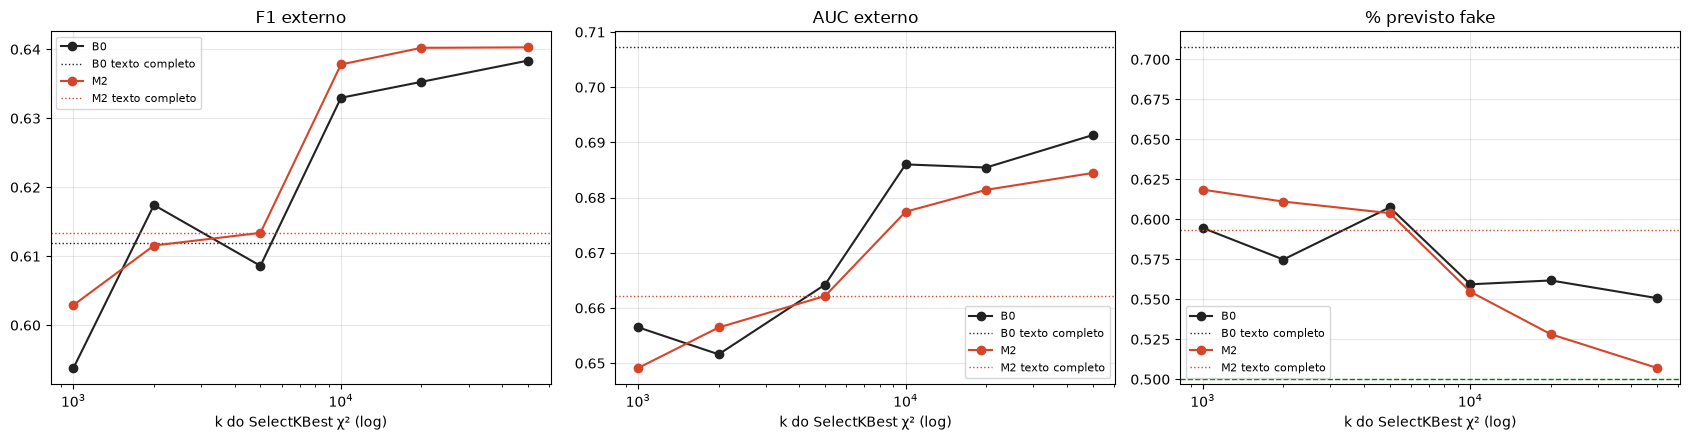

In [8]:
ext_df = pd.DataFrame(linhas_ext)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for nome, cor in [("B0", "#222222"), ("M2", "#d6452a")]:
    s = ext_df[(ext_df.config == nome) & ext_df.k_chi2.isin(kx)]
    full = ext_df[(ext_df.config == nome) & (ext_df.k_chi2 == "completo")].iloc[0]
    k = s.k_chi2.astype(int)
    for ax, col in zip(axes, ["f1_macro", "roc_auc", "pct_prev_fake"]):
        ax.plot(k, s[col], "-o", color=cor, label=nome)
        ax.axhline(full[col], color=cor, ls=":", lw=1, label=f"{nome} texto completo")
for ax, t in zip(axes, ["F1 externo", "AUC externo", "% previsto fake"]):
    ax.set_xscale("log"); ax.set_xlabel("k do SelectKBest χ² (log)"); ax.set_title(t); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[2].axhline(0.5, color="green", ls="--", lw=1)
plt.tight_layout()
plt.show()

**Conclusão (espiada, não escolhe nada):** o χ² **piora a transferência** para os títulos.
- **B0:** o AUC cai de 0,707 (SVD500 sem χ²) para 0,652–0,691 com χ².
- **M2:** k=10 mil dá AUC 0,677 e o melhor, k=50 mil, dá 0,685. Ambos ficam acima do M2 com texto completo (0,662), mas abaixo do B0 completo (0,707).
- O ganho de F1 externo (até 0,640) vem de novo do limiar: o % previsto fake cai para 51–55%.
- **Leitura:** o χ² escolhe os n-gramas mais discriminativos **do Fake.br**. Isso ajuda dentro do corpus e prende o modelo a ele, o oposto do que se quer para generalizar entre fontes.

## 6. Conclusões

1. **Filtrar o TF-IDF por χ² antes do SVD(500) é a melhor forma de reduzir que testamos.** O M2 com k=10 mil chega a F1 CV **0,9295**, igual ao SVM atual (B0 completo), com **gap 0,042 contra 0,0705** (F1 treino 0,97 contra 1,00). É menos ajuste ao treino com a mesma validação.
2. **Ainda não supera o M2 com texto completo** (0,9344): perde ~0,005, de forma consistente nos folds. Em F1 interno puro, o M2 completo continua à frente.
3. **O spaCy rende mais nesse regime:** +0,010 com χ² 10 mil + SVD contra +0,005 no texto completo. Com o texto comprimido, os metadados ganham peso relativo.
4. **No teste interno não há perda:** F1 0,9243 contra 0,9222 do B0, com AUC levemente menor (0,979 contra 0,983), tudo dentro do ruído.
5. **Fora do domínio (espiada), o χ² piora a ordenação.** O AUC do B0 cai de 0,707 para ~0,69, e o M2 com k=10 mil fica em 0,677. O χ² especializa o modelo nos n-gramas que separam o **Fake.br**. A redução de gap é contra o próprio corpus e não resolve o overfitting de domínio.

**Recomendação:** se o objetivo é um modelo com spaCy, menos ajuste ao treino e o mesmo F1 do SVM atual, o candidato é o **M2 com χ² k=10 mil + SVD(500), C=1, w=0,03**. Ele não melhora a generalização para outras fontes: no externo, continua abaixo do B0 completo (AUC 0,677 contra 0,707).